In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

## Integral de Gondolo–Silk para rho'(r)

In [67]:
G = 4.30091e-3       # pc (km/s)^2 / Msun
clight = 299792.458  # km/s

In [68]:
def schwarzschild_radius(M, G=G, clight=clight):
    return 2.0 * G * M / clight**2


def energy_lower_bound(r, M, G=G, clight=clight):
    return -G * M / r * (1.0 - 4.0 * schwarzschild_radius(M, G=G, clight=clight) / r)


def angular_momentum_capture(M, G=G, clight=clight):
    return 2.0 * clight * schwarzschild_radius(M, G=G, clight=clight)


def angular_momentum_max(Ep, r, M, G=G):
    return np.sqrt(np.maximum(2.0 * r**2 * (Ep + G * M / r), 0.0))


def radial_velocity(Ep, Lp, r, M, G=G):
    return np.sqrt(np.maximum(2.0 * (Ep + G * M / r - Lp**2 / (2.0 * r**2)), 0.0))

$$
v_r =
\left[
2\left(
E' + \frac{GM}{r} - \frac{{L'}^2}{2r^2}
\right)
\right]^{1/2}
\qquad
\left[
v_r
\right]
= \mathrm{km}\,\mathrm{s}^{-1},
\tag{2}
$$

$$
E'_m =
-\frac{GM}{r}
\left(
1 - \frac{4R_S}{r}
\right)
\qquad
\left[
E'_m
\right]
= (\mathrm{km}\,\mathrm{s}^{-1})^2,
\tag{3}
$$

$$
L'_c = 2cR_S
\qquad
\left[
L'_c
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1},
\tag{4}
$$

$$
L'_m =
\left[
2r^2
\left(
E' + \frac{GM}{r}
\right)
\right]^{1/2}
\qquad
\left[
L'_m
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}.
\tag{5}
$$


In [69]:
def rho_prime_at_r(f_prime,r,M,G=G,clight=clight,epsabs=0.0,epsrel=1e-6,limit=100):
    if r <= 0.0:
        raise ValueError("r must be positive.")

    R_S = schwarzschild_radius(M, G=G, clight=clight)
    if r <= 4.0 * R_S:
        return 0.0

    E_m = energy_lower_bound(r, M, G=G, clight=clight)
    L_c = angular_momentum_capture(M, G=G, clight=clight)
    L_c2 = L_c**2

    def inner(Ep):
        L_m = angular_momentum_max(Ep, r, M, G=G)
        L_m2 = L_m**2
        if L_m2 <= L_c2:
            return 0.0

        u_max = np.sqrt(L_m2 - L_c2)

        def u_integrand(u):
            return f_prime(Ep, np.sqrt(np.maximum(L_m2 - u**2, 0.0)))

        value, _ = quad(u_integrand,0.0,u_max,epsabs=epsabs,epsrel=epsrel,limit=limit)
        return 4.0 * np.pi / r * value

    rho, _ = quad(inner,E_m,0.0,epsabs=epsabs,epsrel=epsrel,limit=limit)
    return rho

$$
\rho'(r) =
\int_{E'_m}^{0} dE'
\int_{L'_c}^{L'_m} dL'\,
\frac{4\pi L'}{r^2 v_r}\,
f'(E', L')
\qquad
\left[
\rho'
\right]
= M_\odot\,\mathrm{pc}^{-3}
\tag{1}
$$


In [70]:
def rho_prime_profile(f_prime, r_array, M, **kwargs):
    return np.array([rho_prime_at_r(f_prime, r, M, **kwargs) for r in r_array])

In [71]:
M = 2.6e6        # Msun
rho0 = 1.0       # Msun / pc^3
sigma_v = 100.0  # km/s

f0 = rho0 * (2*np.pi*sigma_v**2)**(-1.5)

def f_prime_const(Ep, Lp):
    return f0


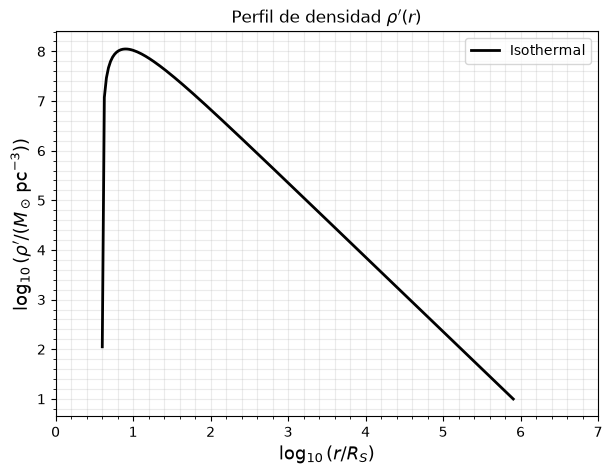

In [72]:
R_S = schwarzschild_radius(M)

r_values = np.logspace(np.log10(4.0001 * R_S),np.log10(0.2),200)
rho_values = rho_prime_profile(f_prime_const, r_values, M)
x_values = np.log10(r_values / R_S)
y_values = np.log10(rho_values)

plt.figure(figsize=(7, 5))
plt.plot(x_values,y_values,color="black",lw=2,label="Isothermal")
plt.xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
plt.ylabel(r"$\log_{10}(\rho'/(M_\odot\,\mathrm{pc}^{-3}))$", fontsize=13)
plt.title(r"Perfil de densidad $\rho'(r)$")
plt.xlim(0, 7)
plt.grid(True, which="both", alpha=0.25)
plt.minorticks_on()
plt.legend(frameon=True)

plt.show()


## Evolución adiabática

Construimos la DF final cuspidada mediante

$$
f'(E',L') = f_i(E,L'),
\qquad
I_i(E,L') = I_f(E',L').
$$

Aquí \(E'>0\) no se usa para órbitas ligadas: en el potencial kepleriano final usamos `Ep < 0`. La energía inicial \(E\) de Gondolo-Silk es positiva.


In [73]:
from scipy.optimize import root_scalar
from scipy.special import gammaln
from scipy.special import beta as beta_function


### Gondolo-Silk cusp model

$$
\rho_i(r) =
\rho_0
\left(\frac{r}{r_0}\right)^{-\gamma},
\qquad
\left[\rho_i\right]=M_\odot\,\mathrm{pc}^{-3}.
$$

$$
\phi_0 =
\frac{4\pi G r_0^2\rho_0}{(3-\gamma)(2-\gamma)},
\qquad
\left[\phi_0\right]=(\mathrm{km}\,\mathrm{s}^{-1})^2.
$$

$$
\beta=\frac{6-\gamma}{2(2-\gamma)},
\qquad
p=\frac{4-\gamma}{2(2-\gamma)}.
$$

$$
f_i(E,L)=
\frac{\rho_0}{(2\pi\phi_0)^{3/2}}
\frac{\Gamma(\beta)}{\Gamma(\beta-3/2)}
\left(\frac{\phi_0}{E}\right)^\beta,
\qquad
\left[f_i\right]=M_\odot\,\mathrm{pc}^{-3}
(\mathrm{km}\,\mathrm{s}^{-1})^{-3}.
$$


In [74]:
def gs_phi0(gamma, rho0, r0, G=G):
    """Return the initial cusp potential scale phi0 in (km/s)^2."""
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    if rho0 <= 0.0:
        raise ValueError("rho0 must be positive.")
    if r0 <= 0.0:
        raise ValueError("r0 must be positive.")
    return 4.0 * np.pi * G * r0**2 * rho0 / ((3.0 - gamma) * (2.0 - gamma))


def gs_beta_exponent(gamma):
    """Return the beta exponent in GS Eq. (7)."""
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return (6.0 - gamma) / (2.0 * (2.0 - gamma))


def gs_action_exponent(gamma):
    """Return the p exponent in GS Eq. (8)."""
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return (4.0 - gamma) / (2.0 * (2.0 - gamma))


def gs_lambda(gamma):
    """Return the dimensionless lambda coefficient in GS Eq. (8)."""
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return (
        (2.0 / (4.0 - gamma))**(1.0 / (2.0 - gamma))
        * ((2.0 - gamma) / (4.0 - gamma))**0.5
    )


def gs_b(gamma):
    """Return the dimensionless b coefficient in GS Eq. (8)."""
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return np.pi * (2.0 - gamma) / beta_function(1.0 / (2.0 - gamma), 1.5)


def f_initial_gs_eq7(E, L, gamma, rho0, r0, G=G):
    """Return GS Eq. (7) initial DF in Msun pc^-3 (km/s)^-3."""
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    if E <= 0.0:
        raise ValueError("Initial GS energy E must be positive.")
    if rho0 <= 0.0:
        raise ValueError("rho0 must be positive.")
    if r0 <= 0.0:
        raise ValueError("r0 must be positive.")

    phi0 = gs_phi0(gamma, rho0, r0, G=G)
    beta = gs_beta_exponent(gamma)
    if phi0 <= 0.0 or beta <= 1.5:
        raise ValueError("Invalid GS cusp parameters.")

    log_f = (
        np.log(rho0)
        - 1.5 * np.log(2.0 * np.pi * phi0)
        + gammaln(beta)
        - gammaln(beta - 1.5)
        + beta * (np.log(phi0) - np.log(E))
    )
    return np.exp(log_f)


### Adiabatic mapping

La acción inicial aproximada de Gondolo-Silk es

$$
I_i(E,L)=
\frac{2\pi}{b}
\left[
-\frac{L}{\lambda}
+\sqrt{2r_0^2\phi_0}
\left(\frac{E}{\phi_0}\right)^p
\right],
\qquad
\left[I_i\right]=\mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}.
$$

La acción radial final kepleriana se evalúa numéricamente:

$$
I_f(E',L') =
2\int_{r_\mathrm{peri}}^{r_\mathrm{apo}}
v_r(E',L',r)\,dr.
$$


In [75]:
def radial_action_initial_gs_eq8(E, L, gamma, rho0, r0, G=G):
    """Return GS Eq. (8) initial radial action in pc km/s."""
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    if E <= 0.0:
        raise ValueError("Initial GS energy E must be positive.")
    if L < 0.0:
        raise ValueError("L must be non-negative.")

    phi0 = gs_phi0(gamma, rho0, r0, G=G)
    p = gs_action_exponent(gamma)
    lam = gs_lambda(gamma)
    b = gs_b(gamma)

    return (2.0 * np.pi / b) * (
        -L / lam + np.sqrt(2.0 * r0**2 * phi0) * (E / phi0)**p
    )


def kepler_turning_points(Ep, Lp, M, G=G, tol=1e-12):
    """Return keplerian periapsis and apoapsis in pc for a bound orbit."""
    if Ep >= 0.0:
        raise ValueError("Ep must be negative for a bound keplerian orbit.")
    if Lp < 0.0:
        raise ValueError("Lp must be non-negative.")
    if M <= 0.0:
        raise ValueError("M must be positive.")

    mu = G * M
    a = -mu / (2.0 * Ep)
    e2 = 1.0 + 2.0 * Ep * Lp**2 / mu**2

    if e2 < 0.0:
        if e2 >= -tol:
            e2 = 0.0
        else:
            raise ValueError(f"Computed e^2 is negative beyond tolerance: e2={e2}.")
    if e2 > 1.0 + tol:
        raise ValueError(f"Computed e^2 is larger than 1 for a bound orbit: e2={e2}.")

    e = np.sqrt(min(e2, 1.0))
    r_peri = a * (1.0 - e)
    r_apo = a * (1.0 + e)

    if r_peri <= 0.0:
        raise ValueError(f"Invalid periapsis: r_peri={r_peri}.")
    if r_apo < r_peri:
        raise ValueError(f"Invalid apoapsis: r_apo={r_apo}, r_peri={r_peri}.")

    return r_peri, r_apo

def radial_action_final_kepler(Ep, Lp, M, G=G):
    """Final radial action in the Keplerian potential of the black hole.

    I_f(E', L') = 2*pi[-L' + GM/sqrt(-2E')]

    Valid for bound final orbits E' < 0.
    """
    if Ep >= 0.0:
        return np.nan
    return 2.0 * np.pi * (-Lp + G * M / np.sqrt(-2.0 * Ep))


def solve_initial_energy_from_action(
    Ep,
    Lp,
    M,
    radial_action_initial,
    E_bracket,
    action_args=(),
    final_action_func=radial_action_final_kepler,
    G=G,
    xtol=1e-10,
    rtol=1e-10,
):
    """Solve E from I_i(E, Lp) = I_f(Ep, Lp) using root_scalar."""
    I_target = final_action_func(Ep, Lp, M, G=G)

    if callable(E_bracket):
        E_min, E_max = E_bracket(Ep, Lp, I_target)
    else:
        E_min, E_max = E_bracket

    if E_min <= 0.0 or E_max <= 0.0 or E_max <= E_min:
        raise ValueError(f"Invalid positive energy bracket: {(E_min, E_max)}.")

    def action_residual(E):
        return radial_action_initial(E, Lp, *action_args) - I_target

    f_min = action_residual(E_min)
    f_max = action_residual(E_max)
    if not np.isfinite(f_min) or not np.isfinite(f_max) or f_min * f_max > 0.0:
        raise ValueError(
            "Initial-energy bracket does not change sign for action conservation. "
            f"Ep={Ep}, Lp={Lp}, I_target={I_target}, E_min={E_min}, E_max={E_max}, "
            f"residual(E_min)={f_min}, residual(E_max)={f_max}."
        )

    solution = root_scalar(action_residual, bracket=(E_min, E_max), xtol=xtol, rtol=rtol)
    if not solution.converged:
        raise RuntimeError(
            "root_scalar did not converge while solving action conservation. "
            f"Ep={Ep}, Lp={Lp}, E_bracket={(E_min, E_max)}."
        )
    return solution.root


### Final distribution function

$$
f'(E',L') = f_i(E,L'),
\qquad
I_i(E,L')=I_f(E',L').
$$


In [76]:
def make_f_prime_gs_cusp(
    gamma,
    rho0,
    r0,
    M,
    E_bracket,
    G=G,
    final_action_func=radial_action_final_kepler,
    return_zero_on_fail=False,
):
    """Build f_prime_adiabatic(Ep, Lp) using root_scalar action matching."""
    gs_phi0(gamma, rho0, r0, G=G)
    action_args = (gamma, rho0, r0)

    def f_prime_adiabatic(Ep, Lp):
        if Ep >= 0.0:
            return 0.0

        try:
            E_initial = solve_initial_energy_from_action(
                Ep=Ep,
                Lp=Lp,
                M=M,
                radial_action_initial=radial_action_initial_gs_eq8,
                E_bracket=E_bracket,
                action_args=action_args,
                final_action_func=final_action_func,
                G=G,
            )
            return f_initial_gs_eq7(E_initial, Lp, gamma, rho0, r0, G=G)
        except Exception:
            if return_zero_on_fail:
                return 0.0
            raise

    return f_prime_adiabatic


In [77]:
gamma = 1.0

D_pc = 8.5e3  # pc, distancia solar al centro galactico

# Normalizacion conservadora aproximada usada por Gondolo-Silk:
# rho_D/(1 - gamma/3) = 0.0062 Msun pc^-3.
rho_D = 0.0062 * (1.0 - gamma / 3.0)  # Msun pc^-3
r0 = D_pc
rho0 = rho_D
phi0 = gs_phi0(gamma, rho0, r0, G=G)


def E_bracket_gs_example(Ep, Lp, I_target):
    """Broad positive-energy bracket for solving I_i(E, Lp) = I_f(Ep, Lp)."""
    return (1e-12 * phi0, 1e12 * phi0)


f_prime_adiabatic = make_f_prime_gs_cusp(
    gamma=gamma,
    rho0=rho0,
    r0=r0,
    M=M,
    E_bracket=E_bracket_gs_example,
    final_action_func=radial_action_final_kepler,
    return_zero_on_fail=False,
)


### Final density integral

La densidad final cuspidada usa la función `rho_prime_profile` definida en la parte isotérmica:

$$
\rho'(r) =
\int dE' \int dL'\,
\frac{4\pi L'}{r^2v_r}
f'(E',L').
$$


In [80]:
R_S = schwarzschild_radius(M)
r_values_adiabatic = np.logspace(np.log10(4.001 * R_S), np.log10(0.2), 200)

rho_values_adiabatic = rho_prime_profile(
    f_prime_adiabatic,
    r_values_adiabatic,
    M,
    epsrel=1e-5,
    limit=100,
)

x_values_adiabatic = np.log10(r_values_adiabatic / R_S)
positive_mask = rho_values_adiabatic > 0

if not np.any(positive_mask):
    raise ValueError("No positive density values were obtained.")

x_plot = x_values_adiabatic[positive_mask]
y_plot = np.log10(rho_values_adiabatic[positive_mask])


### Plot of the cusped final profile


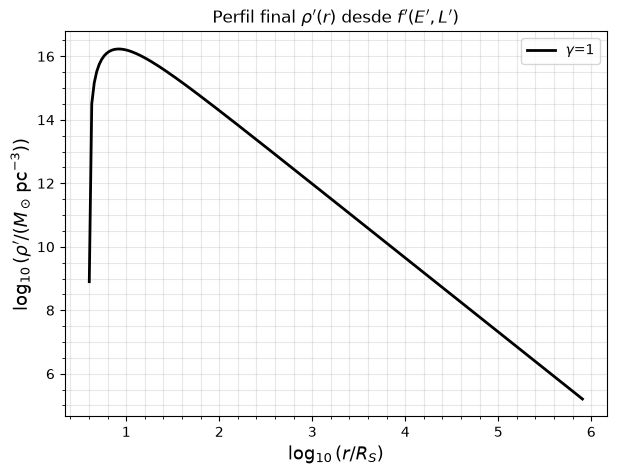

In [87]:
plt.figure(figsize=(7, 5))
plt.plot(x_plot, y_plot, lw=2, color="black", label=r"$\gamma$=1")
plt.xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
plt.ylabel(r"$\log_{10}(\rho'/(M_\odot\,\mathrm{pc}^{-3}))$", fontsize=13)
plt.title(r"Perfil final $\rho'(r)$ desde $f'(E',L')$")
plt.grid(True, which="both", alpha=0.3)
plt.minorticks_on()
plt.legend()
plt.show()
